# Interpretability-Aware Student Academic Risk Prediction

## Exploratory Analysis and Modeling Notebook

This notebook contains the complete exploratory data analysis, feature engineering experiments, interpretability analysis, and Logistic Regression modeling pipeline for academic risk prediction using the UCI Student Performance Dataset.

The primary objective of this analysis is not only to achieve predictive performance, but also to study:
- feature stability
- coefficient interpretability
- multicollinearity effects
- behavioral risk indicators
- cross-subject generalization patterns

Datasets analyzed:
- Mathematics student performance dataset
- Portuguese language student performance dataset

## Notebook Workflow

This notebook follows the following analytical pipeline:

1. Data loading and overview
2. Target variable construction
3. Exploratory data analysis
4. Bivariate analysis
5. Multivariate interaction analysis
6. Feature engineering experiments
7. Feature selection rationale
8. Logistic Regression interpretation
9. Comparative modeling analysis
10. Cross-subject generalization insights

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

## Load Data

## Student Performance Dataset Attributes

### Common Attributes (for both `student-mat.csv` and `student-por.csv`)

1. **school** – Student's school  
   - Binary: `GP` (Gabriel Pereira) or `MS` (Mousinho da Silveira)

2. **sex** – Student's sex  
   - Binary: `F` (female) or `M` (male)

3. **age** – Student's age  
   - Numeric: 15 to 22

4. **address** – Home address type  
   - Binary: `U` (urban) or `R` (rural)

5. **famsize** – Family size  
   - Binary: `LE3` (≤3) or `GT3` (>3)

6. **Pstatus** – Parent's cohabitation status  
   - Binary: `T` (living together) or `A` (apart)

7. **Medu** – Mother's education  
   - Numeric:  
     - 0 = none  
     - 1 = primary (4th grade)  
     - 2 = 5th–9th grade  
     - 3 = secondary education  
     - 4 = higher education  

8. **Fedu** – Father's education  
   - Numeric (same scale as `Medu`)

9. **Mjob** – Mother's job  
   - Nominal: `teacher`, `health`, `services`, `at_home`, `other`

10. **Fjob** – Father's job  
    - Nominal: `teacher`, `health`, `services`, `at_home`, `other`

11. **reason** – Reason to choose this school  
    - Nominal: `home`, `reputation`, `course`, `other`

12. **guardian** – Student's guardian  
    - Nominal: `mother`, `father`, `other`

13. **traveltime** – Home-to-school travel time  
    - Numeric:  
      - 1 = <15 min  
      - 2 = 15–30 min  
      - 3 = 30–60 min  
      - 4 = >1 hour  

14. **studytime** – Weekly study time  
    - Numeric:  
      - 1 = <2 hours  
      - 2 = 2–5 hours  
      - 3 = 5–10 hours  
      - 4 = >10 hours  

15. **failures** – Past class failures  
    - Numeric: `n` if 1 ≤ n < 3, else 4

16. **schoolsup** – Extra educational support  
    - Binary: `yes` or `no`

17. **famsup** – Family educational support  
    - Binary: `yes` or `no`

18. **paid** – Extra paid classes (Math or Portuguese)  
    - Binary: `yes` or `no`

19. **activities** – Extra-curricular activities  
    - Binary: `yes` or `no`

20. **nursery** – Attended nursery school  
    - Binary: `yes` or `no`

21. **higher** – Aspires to higher education  
    - Binary: `yes` or `no`

22. **internet** – Internet access at home  
    - Binary: `yes` or `no`

23. **romantic** – In a romantic relationship  
    - Binary: `yes` or `no`

24. **famrel** – Quality of family relationships  
    - Numeric: 1 (very bad) to 5 (excellent)

25. **freetime** – Free time after school  
    - Numeric: 1 (very low) to 5 (very high)

26. **goout** – Going out with friends  
    - Numeric: 1 (very low) to 5 (very high)

27. **Dalc** – Workday alcohol consumption  
    - Numeric: 1 (very low) to 5 (very high)

28. **Walc** – Weekend alcohol consumption  
    - Numeric: 1 (very low) to 5 (very high)

29. **health** – Current health status  
    - Numeric: 1 (very bad) to 5 (very good)

30. **absences** – Number of school absences  
    - Numeric: 0 to 93

31. **G1** – First period grade  
    - Numeric: 0 to 20

32. **G2** – Second period grade  
    - Numeric: 0 to 20

33. **G3** – Final grade (target basis)  
    - Numeric: 0 to 20

In [16]:
df = pd.read_csv('../data/raw/student-mat.csv',sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Data Overview

In [17]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


No.of rows = 395,
No.of columns = 33,
No missing values.

## Missing Values Analysis

In [18]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


## Understand the Target (Grades)

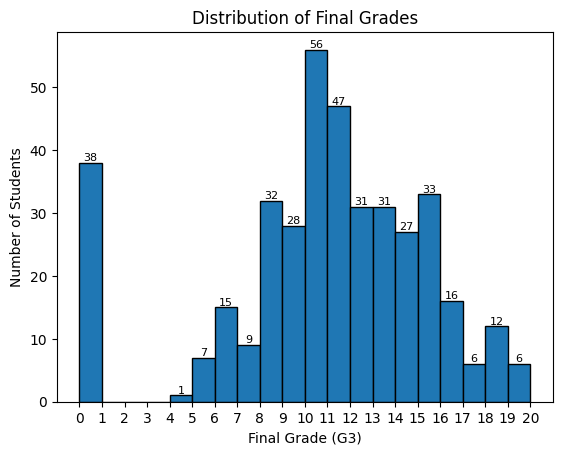

In [19]:
counts, bin_edges, patches =plt.hist(df["G3"], bins=np.arange(0, 21, 1), edgecolor='black')
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.xticks(np.arange(0, 21, 1))
for count, edge in zip(counts, bin_edges[:-1]):
    if count > 0: # only label non-empty bins
        plt.text(edge + 0.5, count, str(int(count)), ha='center', va='bottom', fontsize=8)
plt.show()

## Target Variable Construction

The target variable is constructed as a binary academic-risk label using the final grade (`G3`).

- `at_risk = 1` when `G3 < 10`
- `at_risk = 0` when `G3 >= 10`

This threshold converts final grade outcomes into a practical early-risk classification objective.

In [20]:
df["at_risk"] = (df["G3"] < 10).astype(int)
df["at_risk"].value_counts()

at_risk
0    265
1    130
Name: count, dtype: int64

## Visualization Utilities

In [21]:
def risk_rate(series):
    return pd.crosstab(series, df["at_risk"], normalize="index")


## Bivariate Analysis

### 1. Sex vs at_risk:

In [22]:
risk_rate(df["sex"])


at_risk,0,1
sex,,
F,0.639423,0.360577
M,0.705882,0.294118


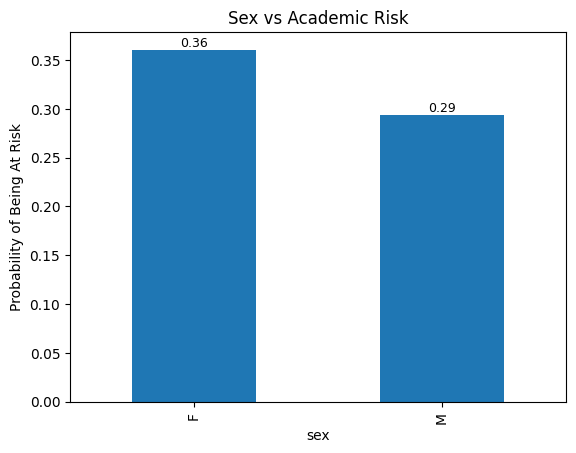

In [23]:
ax=risk_rate(df["sex"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Sex vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",(p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.show()

### 2. Age vs at_risk:

In [24]:
# Bin age into groups for clearer patterns
age_binned = pd.cut(df["age"], bins=[14, 16, 18, 23], labels=["15-16", "17-18", "19+"])
risk_rate(age_binned)

at_risk,0,1
age,,
15-16,0.741935,0.258065
17-18,0.633333,0.366667
19+,0.448276,0.551724


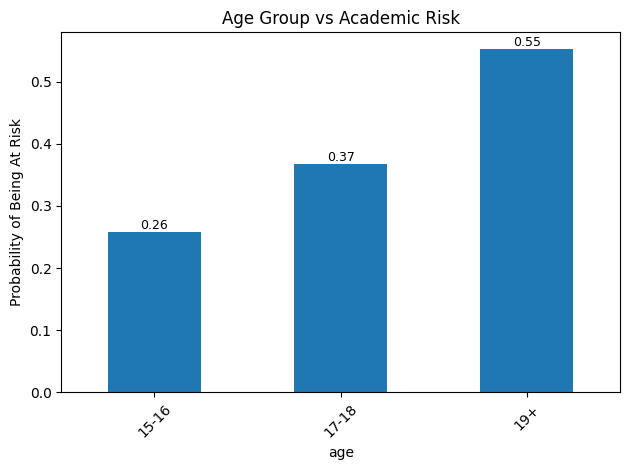

In [25]:
ax = risk_rate(age_binned)[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Age Group vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Address vs at_risk:

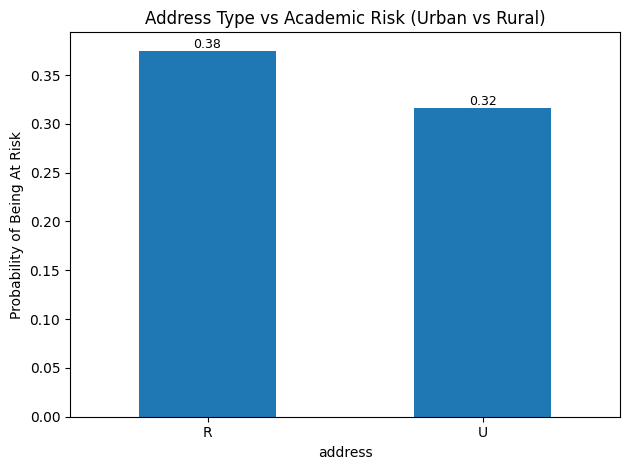

In [26]:
risk_rate(df["address"])
ax = risk_rate(df["address"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Address Type vs Academic Risk (Urban vs Rural)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4. Family Size vs at_risk:

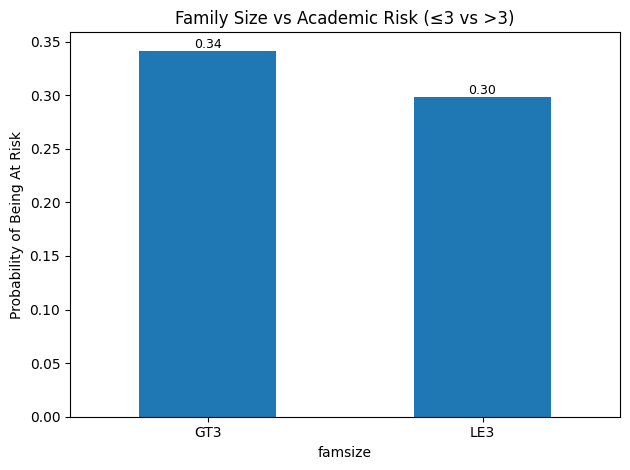

In [27]:
risk_rate(df["famsize"])
ax = risk_rate(df["famsize"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Family Size vs Academic Risk (≤3 vs >3)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Parent Status vs at_risk:

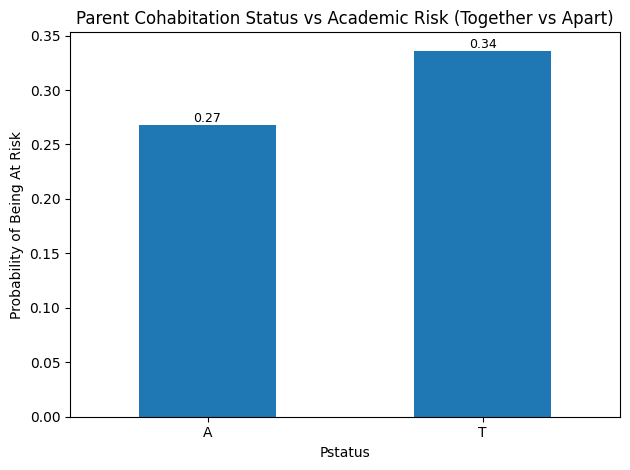

In [28]:
risk_rate(df["Pstatus"])
ax = risk_rate(df["Pstatus"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Parent Cohabitation Status vs Academic Risk (Together vs Apart)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6. Mother's Education vs at_risk:

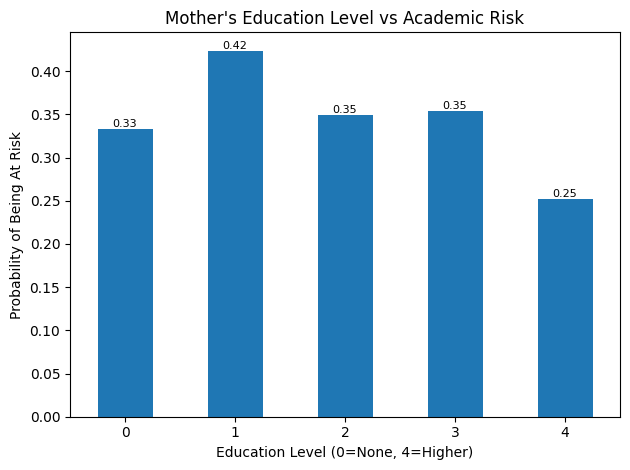

In [29]:
risk_rate(df["Medu"])
ax = risk_rate(df["Medu"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Mother's Education Level vs Academic Risk")
plt.xlabel("Education Level (0=None, 4=Higher)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7. Father's Education vs at_risk:

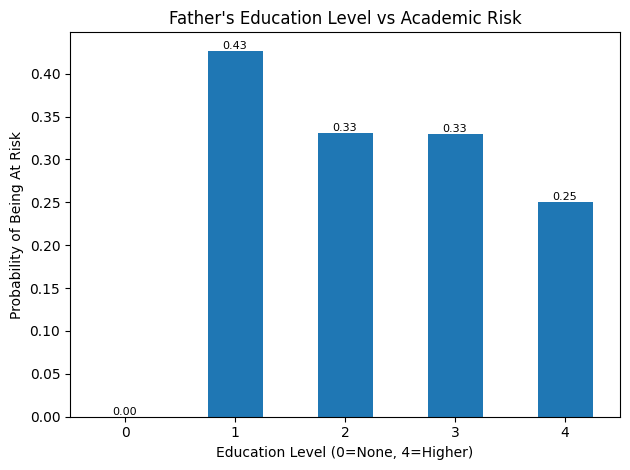

In [30]:
risk_rate(df["Fedu"])
ax = risk_rate(df["Fedu"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Father's Education Level vs Academic Risk")
plt.xlabel("Education Level (0=None, 4=Higher)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8. Mother's Job vs at_risk:

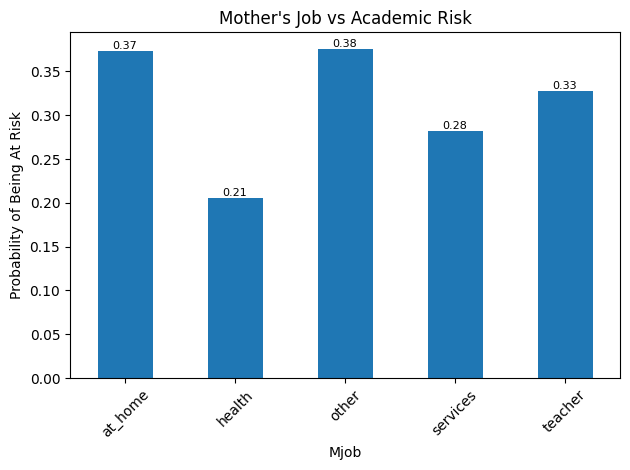

In [31]:
risk_rate(df["Mjob"])
ax = risk_rate(df["Mjob"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Mother's Job vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9. Father's Job vs at_risk:

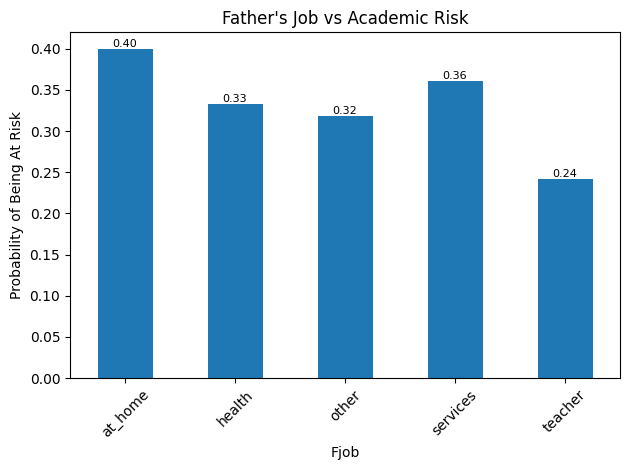

In [32]:
risk_rate(df["Fjob"])
ax = risk_rate(df["Fjob"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Father's Job vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. Reason to Choose School vs at_risk:

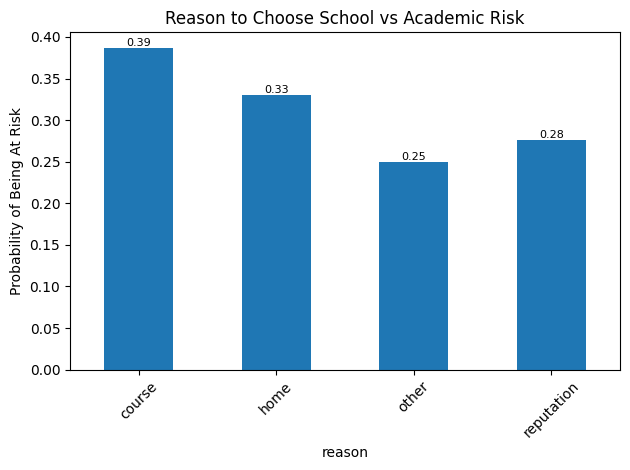

In [33]:
risk_rate(df["reason"])
ax = risk_rate(df["reason"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Reason to Choose School vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 11. Travel Time vs at_risk:

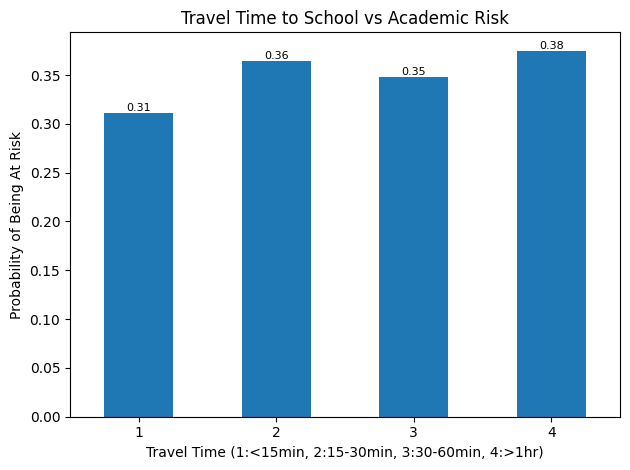

In [34]:
risk_rate(df["traveltime"])
ax = risk_rate(df["traveltime"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Travel Time to School vs Academic Risk")
plt.xlabel("Travel Time (1:<15min, 2:15-30min, 3:30-60min, 4:>1hr)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 12. Study Time vs at_risk:

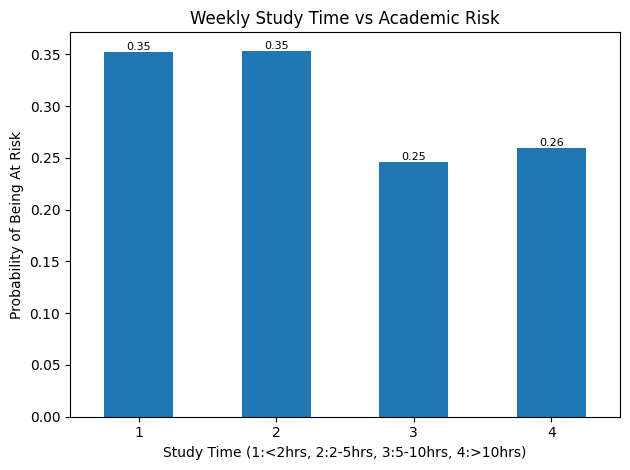

In [35]:
risk_rate(df["studytime"])
ax = risk_rate(df["studytime"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Weekly Study Time vs Academic Risk")
plt.xlabel("Study Time (1:<2hrs, 2:2-5hrs, 3:5-10hrs, 4:>10hrs)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 13. Failures vs at_risk:

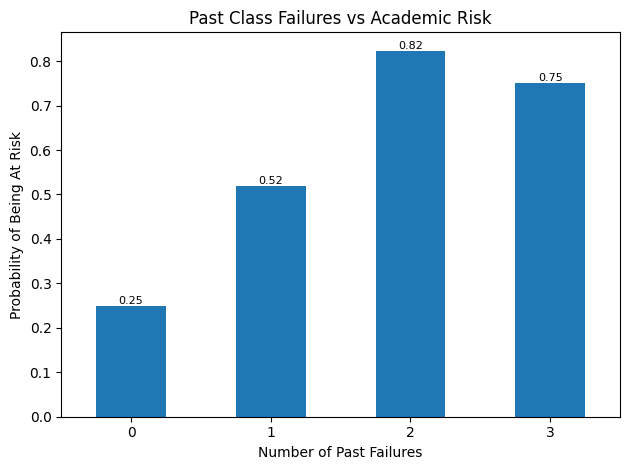

In [36]:
risk_rate(df["failures"])
ax = risk_rate(df["failures"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Past Class Failures vs Academic Risk")
plt.xlabel("Number of Past Failures")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 14. Schoolsup vs at_risk:

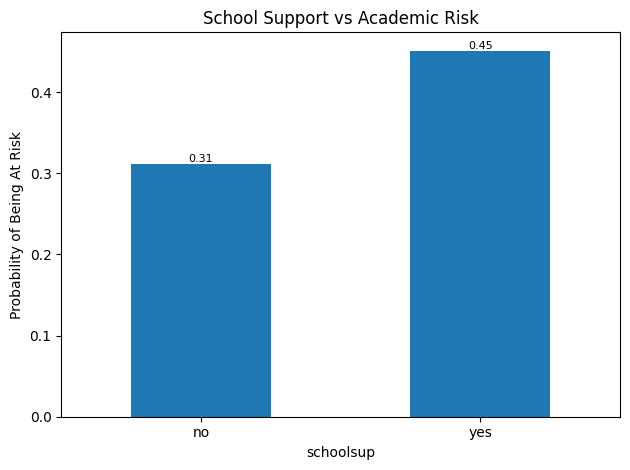

In [37]:
risk_rate(df["schoolsup"])
ax = risk_rate(df["schoolsup"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("School Support vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 15. Famsup vs at_risk:

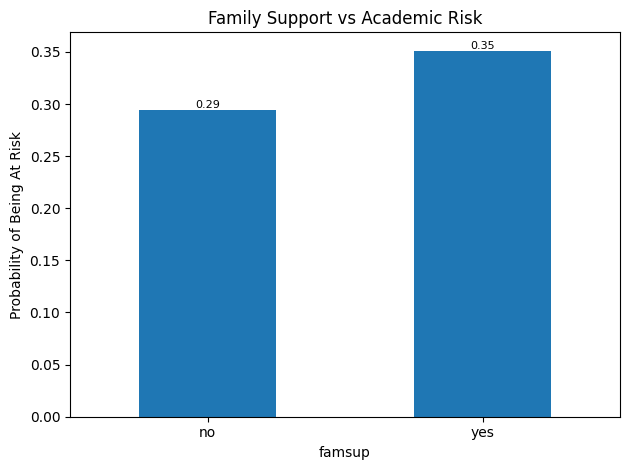

In [38]:
risk_rate(df["famsup"])
ax = risk_rate(df["famsup"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Family Support vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 16. Paid Classes vs at_risk:

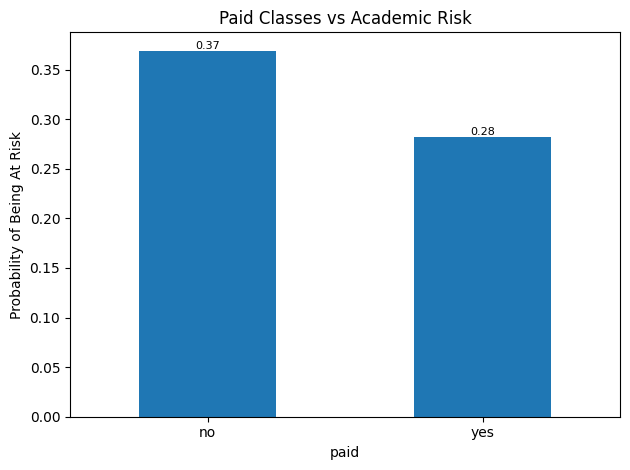

In [39]:
risk_rate(df["paid"])
ax = risk_rate(df["paid"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Paid Classes vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 17. Activities vs at_risk:

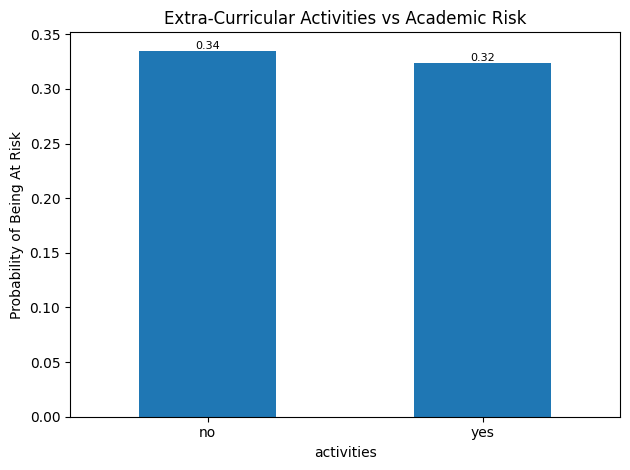

In [40]:
risk_rate(df["activities"])
ax = risk_rate(df["activities"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Extra-Curricular Activities vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 18. Nursery vs at_risk:

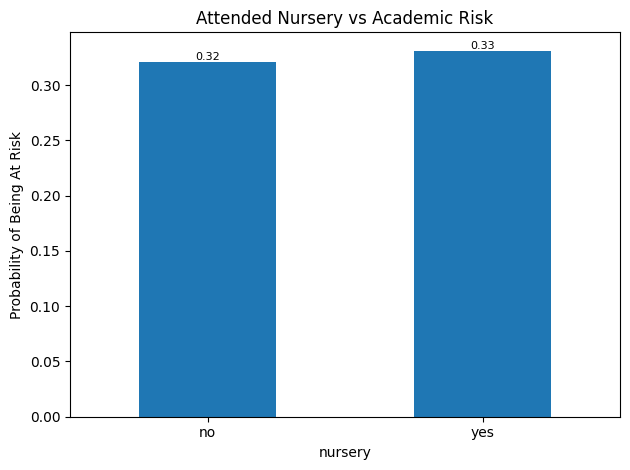

In [41]:
risk_rate(df["nursery"])
ax = risk_rate(df["nursery"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Attended Nursery vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 19. Higher Education Aspiration vs at_risk:

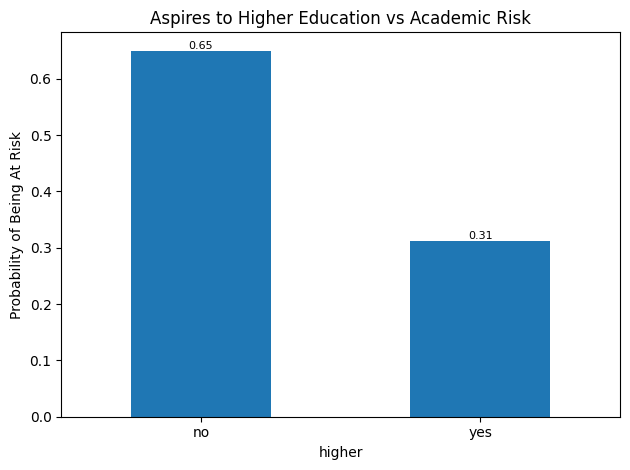

In [42]:
risk_rate(df["higher"])
ax = risk_rate(df["higher"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Aspires to Higher Education vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 20. Internet Access vs at_risk:

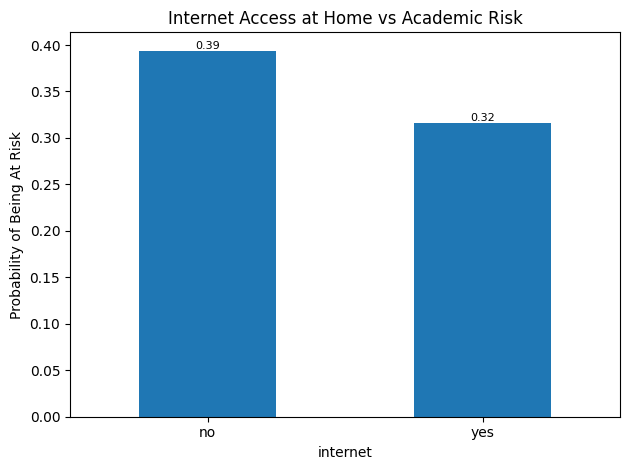

In [43]:
risk_rate(df["internet"])
ax = risk_rate(df["internet"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Internet Access at Home vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 21. Romantic Relationship vs at_risk:

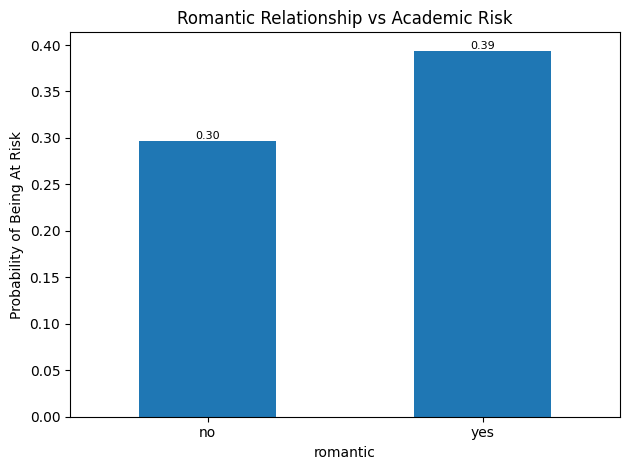

In [44]:
risk_rate(df["romantic"])
ax = risk_rate(df["romantic"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Romantic Relationship vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 22. Family Relationship vs at_risk:

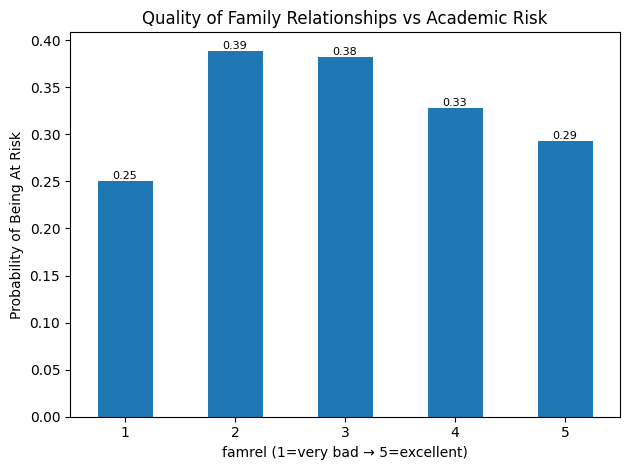

In [45]:
risk_rate(df["famrel"])
ax = risk_rate(df["famrel"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Quality of Family Relationships vs Academic Risk")
plt.xlabel("famrel (1=very bad → 5=excellent)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 23. Free Time vs at_risk:

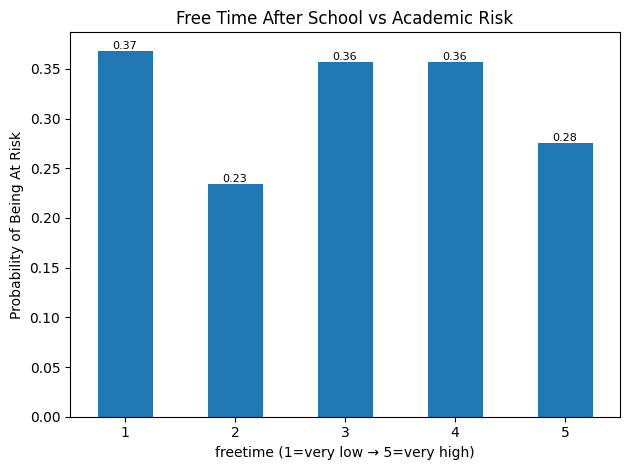

In [46]:
risk_rate(df["freetime"])
ax = risk_rate(df["freetime"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Free Time After School vs Academic Risk")
plt.xlabel("freetime (1=very low → 5=very high)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 24. Going Out vs at_risk:

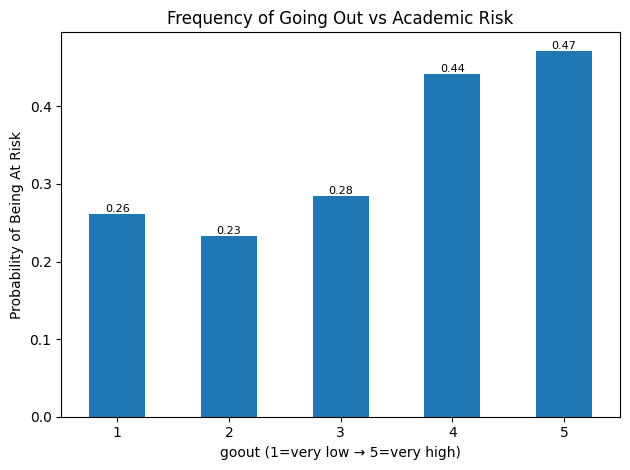

In [47]:
risk_rate(df["goout"])
ax = risk_rate(df["goout"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Frequency of Going Out vs Academic Risk")
plt.xlabel("goout (1=very low → 5=very high)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 25. Workday Alcohol (Dalc) vs at_risk:

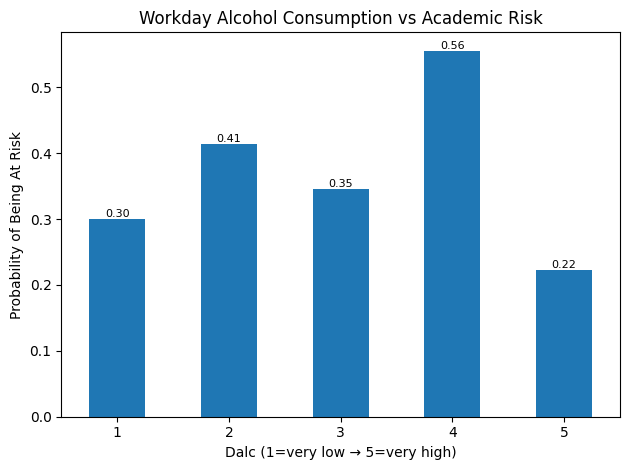

In [48]:
risk_rate(df["Dalc"])
ax = risk_rate(df["Dalc"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Workday Alcohol Consumption vs Academic Risk")
plt.xlabel("Dalc (1=very low → 5=very high)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 26. Weekend Alcohol (Walc) vs at_risk:

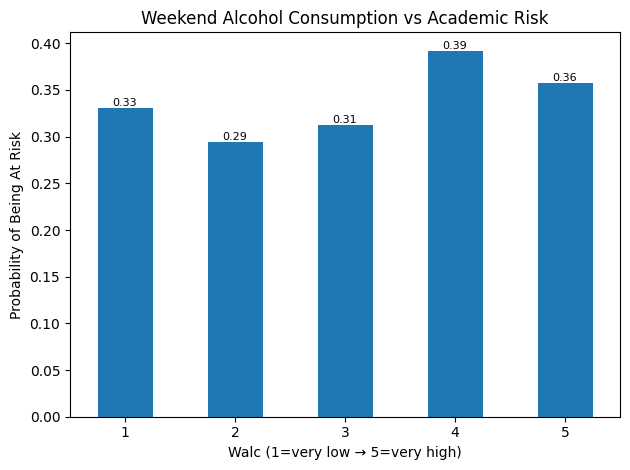

In [49]:
risk_rate(df["Walc"])
ax = risk_rate(df["Walc"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Weekend Alcohol Consumption vs Academic Risk")
plt.xlabel("Walc (1=very low → 5=very high)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 27. Health vs at_risk:

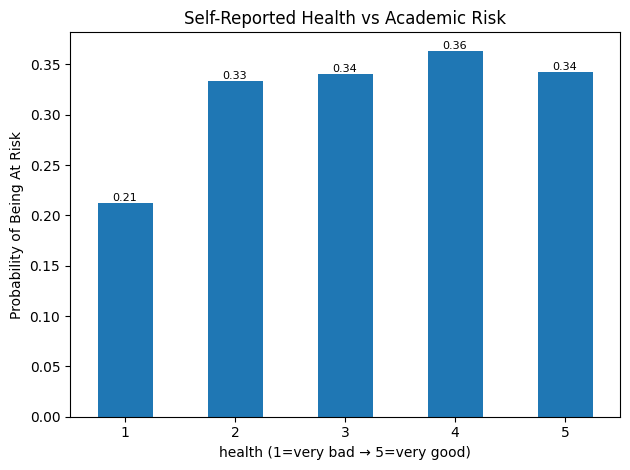

In [50]:
risk_rate(df["health"])
ax = risk_rate(df["health"])[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Self-Reported Health vs Academic Risk")
plt.xlabel("health (1=very bad → 5=very good)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 28. Absences vs at_risk (binned):

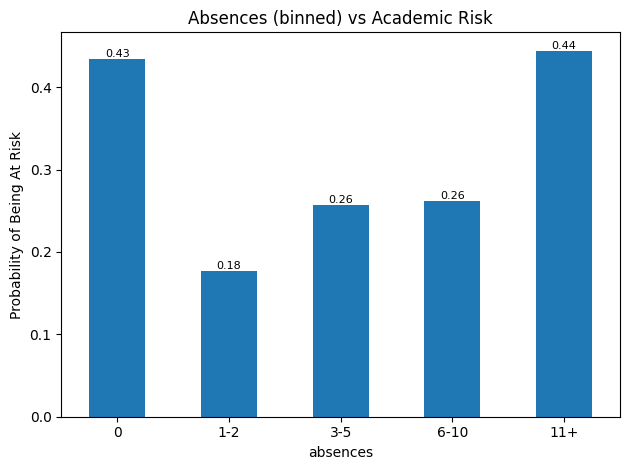

In [51]:
abs_bins = pd.cut(df["absences"], bins=[-1,0,2,5,10,40], labels=["0","1-2","3-5","6-10","11+"])
risk_rate(abs_bins)
ax = risk_rate(abs_bins)[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Absences (binned) vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 29. Grade Trajectory (G2 - G1) vs at_risk:

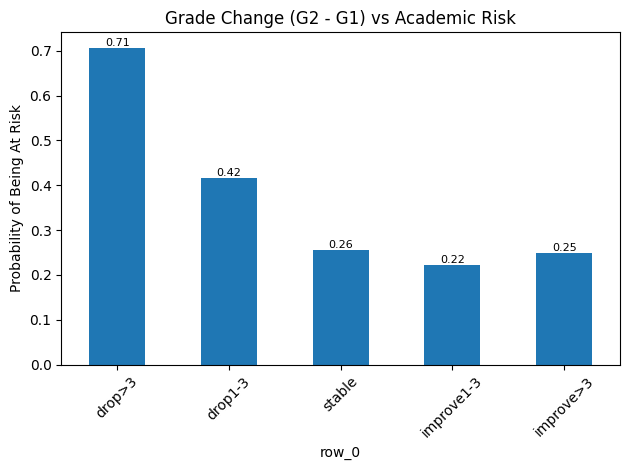

In [52]:
grade_traj = df["G2"] - df["G1"]
risk_rate(pd.cut(grade_traj, bins=[-10,-3, -1,1,3,10], labels=["drop>3","drop1-3","stable","improve1-3","improve>3"]))
ax = pd.crosstab(pd.cut(grade_traj, bins=[-10,-3, -1,1,3,10], labels=["drop>3","drop1-3","stable","improve1-3","improve>3"]), df["at_risk"], normalize="index")[1].plot(kind="bar")
plt.ylabel("Probability of Being At Risk")
plt.title("Grade Change (G2 - G1) vs Academic Risk")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",(p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multivariate Interaction Analysis

### 1. failures × (G2 - G1) vs at_risk

failures × grade_change probability table (rows=failures, cols=grade bins):
row_1       drop>3   drop1-3    stable  improve1-3  improve>3
failures                                                     
0         0.700000  0.354167  0.192547         0.1        0.0
1         0.333333  0.521739  0.642857         0.4        0.0
2         1.000000  0.600000  0.833333         1.0        1.0
3         1.000000  0.833333  0.500000         1.0        0.0


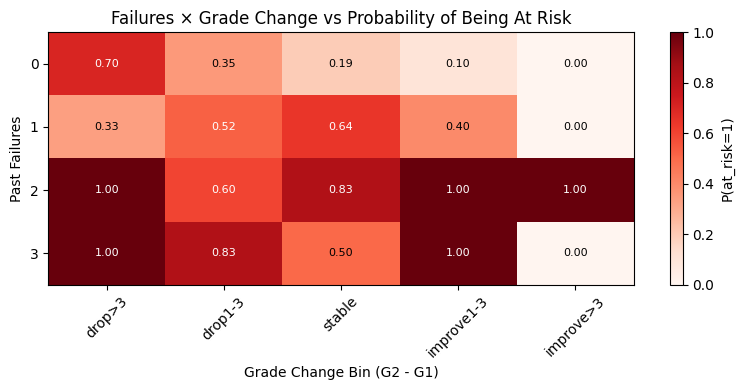

In [53]:
grade_traj = df["G2"] - df["G1"]
grade_bins = pd.cut(grade_traj, bins=[-10, -3, -1, 1, 3, 10], labels=["drop>3", "drop1-3", "stable", "improve1-3", "improve>3"])
ct = pd.crosstab([df["failures"], grade_bins], df["at_risk"], normalize="index")[1].unstack(level=1).fillna(0)
print("failures × grade_change probability table (rows=failures, cols=grade bins):")
print(ct)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(ct.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(ct.shape[1])); ax.set_xticklabels(ct.columns.astype(str), rotation=45)
ax.set_yticks(np.arange(ct.shape[0])); ax.set_yticklabels(ct.index.astype(str))
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white' if val>0.5 else 'black', fontsize=8)
plt.colorbar(im, label='P(at_risk=1)')
ax.set_xlabel('Grade Change Bin (G2 - G1)')
ax.set_ylabel('Past Failures')
ax.set_title('Failures × Grade Change vs Probability of Being At Risk')
plt.tight_layout()
plt.show()

### 2. famsup × Medu × Fedu vs at_risk


famsup=no — Medu × Fedu probability table:
Fedu    0         1         2         3         4
Medu                                             
0     0.0  0.000000  0.000000  0.000000  0.000000
1     0.0  0.444444  0.500000  0.666667  0.000000
2     0.0  0.277778  0.352941  0.222222  0.000000
3     0.0  0.333333  0.250000  0.272727  0.142857
4     0.0  1.000000  0.142857  0.230769  0.187500

famsup=yes — Medu × Fedu probability table:
Fedu    0         1         2        3         4
Medu                                            
0     0.0  1.000000  0.000000  0.00000  0.000000
1     0.0  0.421053  0.200000  0.50000  0.000000
2     0.0  0.600000  0.411765  0.25000  0.166667
3     0.0  0.444444  0.437500  0.37037  0.454545
4     0.0  0.000000  0.083333  0.37037  0.259259


C:\Users\mukhe\AppData\Local\Temp\ipykernel_11824\716436805.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


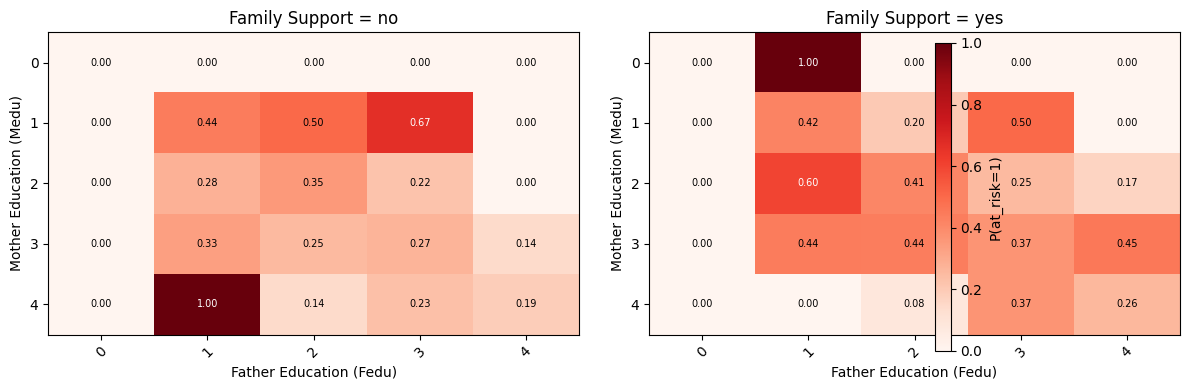

In [54]:
famsup_vals = sorted(df['famsup'].unique())
fig, axes = plt.subplots(1, len(famsup_vals), figsize=(6 * len(famsup_vals), 4), squeeze=False)
for idx, famval in enumerate(famsup_vals):
    sub = df[df['famsup'] == famval]
    ct_sub = pd.crosstab([sub['Medu'], sub['Fedu']], sub['at_risk'], normalize='index')[1].unstack(level=1).fillna(0)
    print(f"\nfamsup={famval} — Medu × Fedu probability table:")
    print(ct_sub)
    ax = axes[0, idx]
    im = ax.imshow(ct_sub.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(np.arange(ct_sub.shape[1])); ax.set_xticklabels(ct_sub.columns.astype(str), rotation=45)
    ax.set_yticks(np.arange(ct_sub.shape[0])); ax.set_yticklabels(ct_sub.index.astype(str))
    for i in range(ct_sub.shape[0]):
        for j in range(ct_sub.shape[1]):
            val = ct_sub.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white' if val>0.5 else 'black', fontsize=7)
    ax.set_title(f'Family Support = {famval}')
    ax.set_xlabel('Father Education (Fedu)')
    ax.set_ylabel('Mother Education (Medu)')
fig.colorbar(im, ax=axes.ravel().tolist(), label='P(at_risk=1)')
plt.tight_layout()
plt.show()

### 3. studytime × absences vs at_risk


studytime × absences probability table (rows=studytime, cols=absences bins):
absences          0       1-2       3-5      6-10       11+
studytime                                                  
1          0.484848  0.090909  0.315789  0.166667  0.555556
2          0.415094  0.186047  0.300000  0.400000  0.435897
3          0.428571  0.181818  0.076923  0.200000  0.200000
4          0.375000  0.333333  0.250000  0.181818  0.000000


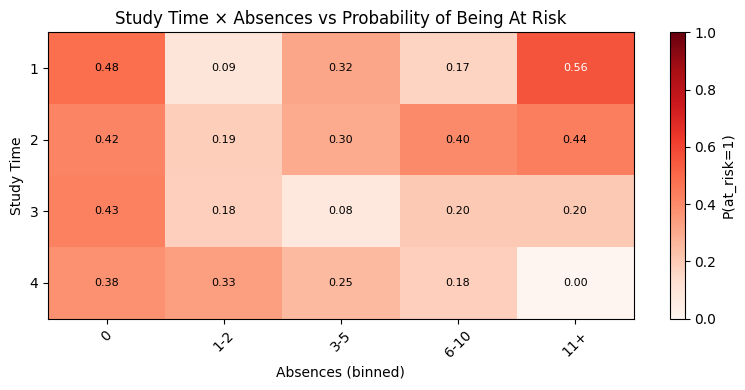

In [55]:
abs_bins = pd.cut(df['absences'], bins=[-1, 0, 2, 5, 10, 40], labels=['0', '1-2', '3-5', '6-10', '11+'])
ct = pd.crosstab([df['studytime'], abs_bins], df['at_risk'], normalize='index')[1].unstack(level=1).fillna(0)
print('\nstudytime × absences probability table (rows=studytime, cols=absences bins):')
print(ct)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(ct.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(ct.shape[1])); ax.set_xticklabels(ct.columns.astype(str), rotation=45)
ax.set_yticks(np.arange(ct.shape[0])); ax.set_yticklabels(ct.index.astype(str))
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white' if val>0.5 else 'black', fontsize=8)
plt.colorbar(im, label='P(at_risk=1)')
ax.set_xlabel('Absences (binned)')
ax.set_ylabel('Study Time')
ax.set_title('Study Time × Absences vs Probability of Being At Risk')
plt.tight_layout()
plt.show()

### 4. goout × Walc vs at_risk


goout × Walc probability table (rows=goout, cols=Walc):
Walc          1         2         3         4       5
goout                                                
1      0.266667  0.500000  0.000000  0.000000  0.0000
2      0.277778  0.137931  0.333333  0.000000  0.5000
3      0.191489  0.324324  0.342857  0.428571  0.2500
4      0.615385  0.333333  0.227273  0.478261  0.5000
5      0.666667  0.666667  0.444444  0.461538  0.3125


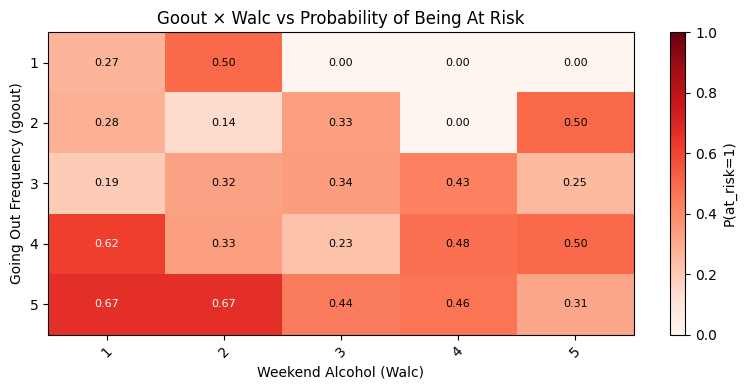

In [56]:
ct = pd.crosstab([df['goout'], df['Walc']], df['at_risk'], normalize='index')[1].unstack(level=1).fillna(0)
print('\ngoout × Walc probability table (rows=goout, cols=Walc):')
print(ct)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(ct.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(ct.shape[1])); ax.set_xticklabels(ct.columns.astype(str), rotation=45)
ax.set_yticks(np.arange(ct.shape[0])); ax.set_yticklabels(ct.index.astype(str))
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white' if val>0.5 else 'black', fontsize=8)
plt.colorbar(im, label='P(at_risk=1)')
ax.set_xlabel('Weekend Alcohol (Walc)')
ax.set_ylabel('Going Out Frequency (goout)')
ax.set_title('Goout × Walc vs Probability of Being At Risk')
plt.tight_layout()
plt.show()

### 5. activities × freetime vs at_risk


activities × freetime probability table (rows=activities, cols=freetime):
freetime           1         2         3         4         5
activities                                                  
no          0.461538  0.242424  0.368421  0.333333  0.266667
yes         0.166667  0.225806  0.345679  0.379310  0.280000


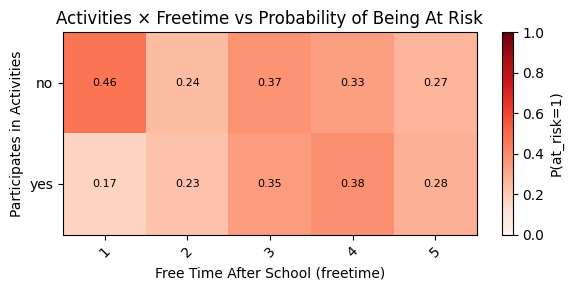

In [57]:
ct = pd.crosstab([df['activities'], df['freetime']], df['at_risk'], normalize='index')[1].unstack(level=1).fillna(0)
print('\nactivities × freetime probability table (rows=activities, cols=freetime):')
print(ct)
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(ct.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(np.arange(ct.shape[1])); ax.set_xticklabels(ct.columns.astype(str), rotation=45)
ax.set_yticks(np.arange(ct.shape[0])); ax.set_yticklabels(ct.index.astype(str))
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white' if val>0.5 else 'black', fontsize=8)
plt.colorbar(im, label='P(at_risk=1)')
ax.set_xlabel('Free Time After School (freetime)')
ax.set_ylabel('Participates in Activities')
ax.set_title('Activities × Freetime vs Probability of Being At Risk')
plt.tight_layout()
plt.show()


### 6. famsup x medu x mjob vs at_risk

Condition 1: famsup='yes' AND Mjob='at_home'
Sample size: 34
Medu vs P(at_risk=1):
Medu
0    1.000000
1    0.250000
2    0.428571
3    0.500000
4    0.000000
Name: 1, dtype: float64

Condition 2: famsup='no'
Sample size: 153
Medu vs P(at_risk=1):
Medu
0    0.000000
1    0.468750
2    0.288889
3    0.250000
4    0.210526
Name: 1, dtype: float64

Condition 3: famsup='yes' AND Mjob != 'at_home'
Sample size: 208
Medu vs P(at_risk=1):
Medu
1    0.466667
2    0.386364
3    0.403509
4    0.271739
Name: 1, dtype: float64



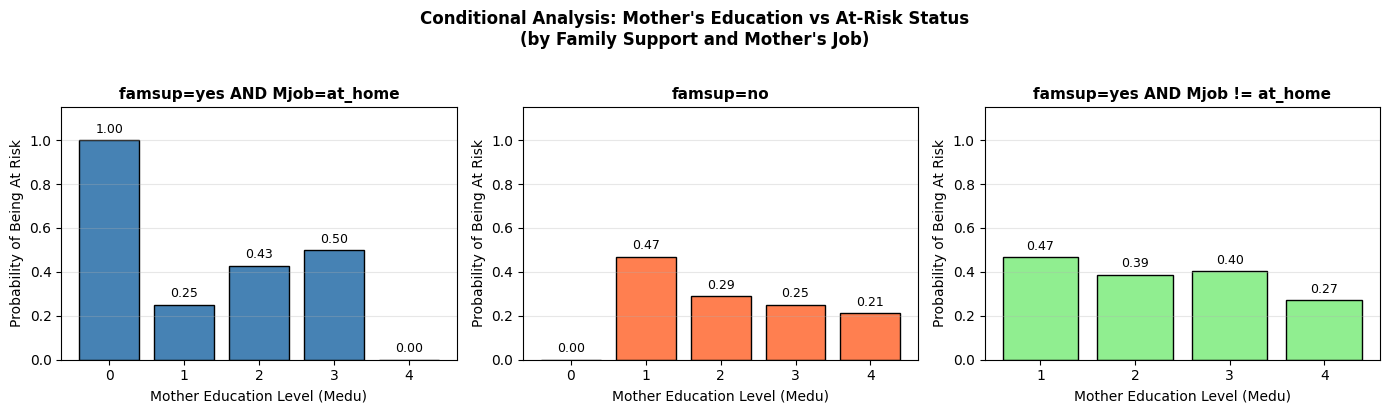

In [58]:
# Condition 1: famsup='yes' AND Mjob='at_home'
filtered_1 = df[(df['famsup'] == 'yes') & (df['Mjob'] == 'at_home')]
ct_1 = pd.crosstab(filtered_1['Medu'], filtered_1['at_risk'], normalize='index')[1]
print("Condition 1: famsup='yes' AND Mjob='at_home'")
print(f"Sample size: {len(filtered_1)}")
print("Medu vs P(at_risk=1):")
print(ct_1)
print()

# Condition 2: famsup='no'
filtered_2 = df[df['famsup'] == 'no']
ct_2 = pd.crosstab(filtered_2['Medu'], filtered_2['at_risk'], normalize='index')[1]
print("Condition 2: famsup='no'")
print(f"Sample size: {len(filtered_2)}")
print("Medu vs P(at_risk=1):")
print(ct_2)
print()

# Condition 3: famsup='yes' AND Mjob!='at_home'
filtered_3 = df[(df['famsup'] == 'yes') & (df['Mjob'] != 'at_home')]
ct_3 = pd.crosstab(filtered_3['Medu'], filtered_3['at_risk'], normalize='index')[1]
print("Condition 3: famsup='yes' AND Mjob != 'at_home'")
print(f"Sample size: {len(filtered_3)}")
print("Medu vs P(at_risk=1):")
print(ct_3)
print()

# Determine consistent y-axis limits
y_max = max(ct_1.max(), ct_2.max(), ct_3.max()) * 1.15
y_min = 0

# Visualization: side-by-side bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: famsup='yes' AND Mjob='at_home'
ax = axes[0]
bars = ax.bar(ct_1.index.astype(str), ct_1.values, color='steelblue', edgecolor='black')
ax.set_ylim([y_min, y_max])
ax.set_xlabel('Mother Education Level (Medu)', fontsize=10)
ax.set_ylabel('Probability of Being At Risk', fontsize=10)
ax.set_title('famsup=yes AND Mjob=at_home', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (idx, val) in enumerate(ct_1.items()):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 2: famsup='no'
ax = axes[1]
bars = ax.bar(ct_2.index.astype(str), ct_2.values, color='coral', edgecolor='black')
ax.set_ylim([y_min, y_max])
ax.set_xlabel('Mother Education Level (Medu)', fontsize=10)
ax.set_ylabel('Probability of Being At Risk', fontsize=10)
ax.set_title('famsup=no', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (idx, val) in enumerate(ct_2.items()):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 3: famsup='yes' AND Mjob!='at_home'
ax = axes[2]
bars = ax.bar(ct_3.index.astype(str), ct_3.values, color='lightgreen', edgecolor='black')
ax.set_ylim([y_min, y_max])
ax.set_xlabel('Mother Education Level (Medu)', fontsize=10)
ax.set_ylabel('Probability of Being At Risk', fontsize=10)
ax.set_title('famsup=yes AND Mjob != at_home', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (idx, val) in enumerate(ct_3.items()):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Conditional Analysis: Mother\'s Education vs At-Risk Status\n(by Family Support and Mother\'s Job)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Observations from Exploratory Data Analysis

This section highlights **key patterns and insights** observed during exploratory and multivariate analysis.
Not all analyzed variables are included here. Only **notable, stable, and interpretable findings** are documented.

---

### Academic History and Performance

- **Past class failures** show the strongest and most consistent relationship with academic risk.
  The probability of being at risk increases sharply with the number of prior failures.

- **Grade trajectory (G2 − G1)** is a powerful indicator of risk.
  Students with significant grade drops exhibit substantially higher risk compared to those with stable or improving performance.

- **Second-period grade (G2)** provides a strong baseline academic signal and complements grade change trends.

---

### Demographic Factors

- **Age** shows a monotonic increase in academic risk, particularly for students aged 19 and above.
  This is interpreted as a proxy for grade repetition or prior academic difficulty rather than age being a causal factor.

---

### Motivation and Behavior

- **Aspiration for higher education** is associated with lower academic risk, suggesting motivation and long-term academic intent play a protective role.

- **Frequency of going out** shows a clear increasing trend in academic risk, indicating that excessive social activity may negatively impact academic outcomes.

---

### Family and Socio-Economic Context

- **Parental education (`Medu`, `Fedu`)** exhibits a moderate relationship with academic risk, but its effect is strongly dependent on family educational support.

- **Family support (`famsup`)** alone does not strongly predict academic risk. However, when combined with parental education, a clearer and more stable relationship emerges.

---

### Conditional Effect of Parental Education and Family Support

A conditional analysis was conducted to understand whether the relationship between parental education and academic risk depends on the presence of active family educational support.

Key observations:

- When **family educational support is present**, higher combined parental education levels are associated with noticeably lower academic risk.
- In the absence of family support, the relationship between parental education and academic risk becomes substantially weaker and less consistent.
- The interaction between parental education and family support produced clearer and more stable patterns than parental employment-status conditions.

These findings suggest that **parental education alone is insufficient** to explain academic outcomes. Its impact becomes meaningful primarily when combined with an enabling and supportive family learning environment.

As a result, a composite engineered feature (`famsup_effective`) was created to represent the interaction between family support and combined parental education, rather than treating these variables independently.

---

### Notable Non-Findings

- **Extra-curricular activities** do not show a meaningful relationship with academic risk, even in multivariate settings.

- **Absences**, when analyzed independently, do not exhibit a consistent or monotonic relationship with academic risk.
  Their impact appears to be conditional rather than direct.

---

### Analytical Considerations

- Some variables (e.g., school support) exhibit strong correlations due to **reverse causality** and are excluded from modeling despite statistical association.
- Feature selection prioritizes **interpretability, stability across analyses, and logical defensibility** over raw correlation strength.


famsup_effective_test vs at_risk probability table:
at_risk                       0         1
famsup_effective_test                    
0                      0.705882  0.294118
1                      0.500000  0.500000
2                      0.578947  0.421053
3                      0.533333  0.466667
4                      0.577778  0.422222
5                      0.625000  0.375000
6                      0.733333  0.266667
7                      0.605263  0.394737
8                      0.740741  0.259259


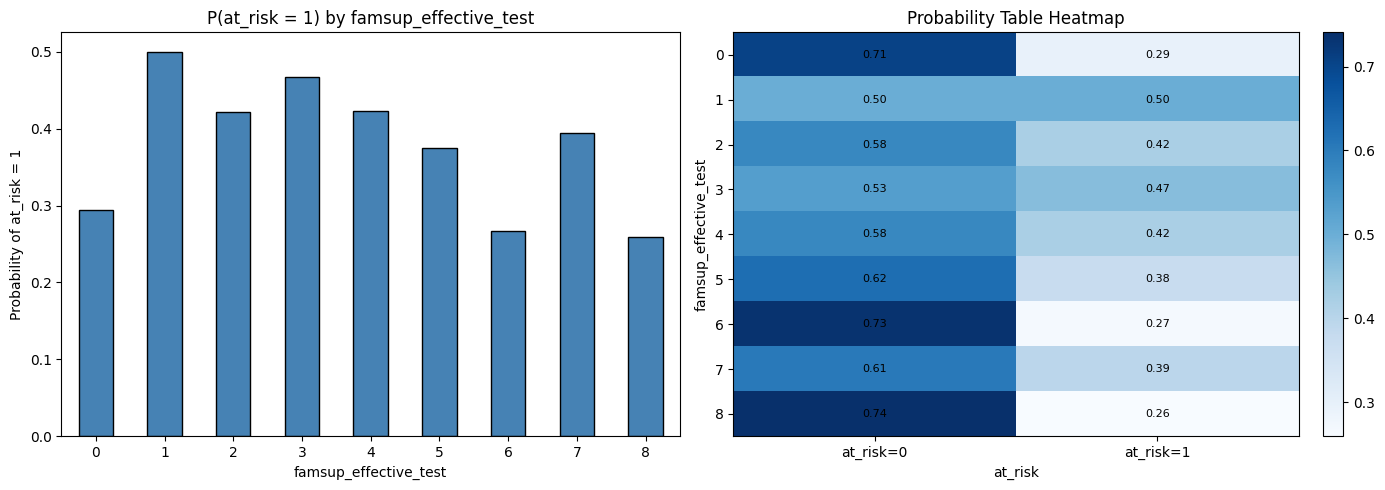

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(r"c:\Users\mukhe\Desktop\student risk prediction")
experimental_df = pd.read_csv(project_root / "data" / "raw" / "student-mat.csv", sep=";")
experimental_df["at_risk"] = (experimental_df["G3"] < 10).astype(int)

# Temporary baseline: family support alone, without parent-at-home conditions.
experimental_df["famsup_effective_test"] = experimental_df["Medu"] + experimental_df["Fedu"]
experimental_df.loc[experimental_df["famsup"] != "yes", "famsup_effective_test"] = 0

prob_table = pd.crosstab(
    experimental_df["famsup_effective_test"],
    experimental_df["at_risk"],
    normalize="index",
).fillna(0)

print("famsup_effective_test vs at_risk probability table:")
print(prob_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manual check: the bar chart should show how the risk probability changes across the test feature values.
prob_table[1].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("P(at_risk = 1) by famsup_effective_test")
axes[0].set_xlabel("famsup_effective_test")
axes[0].set_ylabel("Probability of at_risk = 1")
axes[0].tick_params(axis="x", rotation=0)

heatmap = axes[1].imshow(prob_table.values, aspect="auto", cmap="Blues")
axes[1].set_title("Probability Table Heatmap")
axes[1].set_xlabel("at_risk")
axes[1].set_ylabel("famsup_effective_test")
axes[1].set_xticks(range(len(prob_table.columns)))
axes[1].set_xticklabels([f"at_risk={column}" for column in prob_table.columns])
axes[1].set_yticks(range(len(prob_table.index)))
axes[1].set_yticklabels(prob_table.index)

for row_index in range(prob_table.shape[0]):
    for column_index in range(prob_table.shape[1]):
        axes[1].text(
            column_index,
            row_index,
            f"{prob_table.values[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Feature Engineering Validation Experiment

This baseline checks whether family support alone is enough to carry the signal without requiring parent-at-home conditions. If the probability pattern for `famsup_effective_test` is similar to the conditional feature used elsewhere, then the parent-availability constraint may not be necessary for this dataset.

A simpler family-support feature can be a useful baseline because it is easier to interpret and may generalize better if the parent-at-home condition is too specific or unstable. The existing conditional logic using `Mjob` and `Fjob` remains the stricter version, but this temporary analysis helps test whether that extra specificity is actually needed.

## Feature Selection Rationale

Feature selection for this project was guided by a combination of statistical evidence, multivariate stability, and logical interpretability rather than raw correlation strength alone. The goal was to build a model that is both predictive and defensible, avoiding misleading signals caused by confounding or selection effects.

---

### Included Features

The following features were selected because they demonstrated consistent, interpretable patterns across both bivariate and multivariate analyses:

- **Past class failures (`failures`)**  
  This feature showed the strongest and most stable relationship with academic risk. The probability of being at risk increased sharply and monotonically with the number of prior failures, making it the most informative predictor.

- **Grade trajectory (`grade_change = G2 − G1`)**  
  Captures performance trends rather than static achievement levels. Students with declining grades showed substantially higher academic risk compared to those with stable or improving performance.

- **Second-period grade (`G2`)**  
  Provides a strong academic baseline and complements grade trajectory information without excessive redundancy.

- **Age**  
  Academic risk increased monotonically with age, particularly for students aged 19 and above. This feature is interpreted as a proxy for grade repetition or prior academic difficulty rather than a causal factor.

- **Aspiration for higher education (`higher`)**  
  Students aspiring to higher education showed lower academic risk, suggesting that motivation and long-term academic intent act as protective factors.

- **Frequency of going out (`goout`)**  
  A clear behavioral pattern emerged where higher social activity correlated with increased academic risk. This feature was retained as a lifestyle-related indicator.

- **Study time (`studytime`)**  
  Although weak in isolation, study time provides contextual behavioral information and contributes meaningfully when considered alongside other academic and behavioral variables.

- **Family-supported parental education (`famsup_effective`)** *(engineered feature)*  
  Rather than using parental education or family support independently, a composite feature was engineered to capture their interaction.  

  This feature represents the combined parental education level (`Medu + Fedu`) only when active family educational support is present (`famsup = yes`). Otherwise, the feature is set to zero.

  Exploratory and conditional analysis showed that parental education becomes meaningfully associated with lower academic risk primarily in the presence of active family support. A simplified interaction feature was ultimately preferred over more complex parent-availability conditions because it produced clearer, more stable, and more generalizable patterns.

---

### Excluded Features

Several intuitive features were deliberately excluded after analysis revealed weak, unstable, or misleading relationships:

- **School support (`schoolsup`)**  
  Although statistically associated with higher academic risk, this variable reflects reactive intervention rather than predictive causation. Students receive school support after academic decline has already begun, making it unsuitable for inclusion.

- **Extra-curricular activities (`activities`)**  
  No meaningful relationship with academic risk was observed, even in multivariate settings.

- **Absences (raw)**  
  Absences exhibited non-monotonic and inconsistent patterns when analyzed independently. Their effect appears to be conditional rather than directly predictive.

- **Alcohol consumption variables (`Dalc`, `Walc`)**  
  These variables provided marginal additional signal beyond behavioral indicators and were excluded to reduce noise and ethical ambiguity.

- **Free time (`freetime`)**  
  Weak and inconsistent effects were observed, with substantial overlap with other behavioral features.

---

### Analytical Considerations

Several variables such as school support and study time showed reverse or weak relationships due to selection effects, where interventions occur after academic decline has already begun.

We prioritized features that were stable across bivariate and multivariate analyses, and excluded intuitive but weak predictors to reduce noise and improve generalization.


### Model Interpretation and Feature Stability

Although several engineered and behavioral features showed meaningful patterns during exploratory analysis, not all retained stable directional behavior during Logistic Regression modeling.

In particular:
- `grade_change` exhibited multicollinearity effects due to its mathematical dependency on `G2`
- `studytime` displayed signs of reverse causality, likely reflecting increased study effort after academic decline
- `famsup_effective` showed unstable directional behavior, suggesting that family support may act reactively rather than predictively

These observations reinforced the importance of interpretable baseline modeling and coefficient-level analysis before relying on predictive performance alone.

## Comparative Modeling Insights

Two Logistic Regression configurations were evaluated to study the tradeoff between predictive performance and interpretability.

### Performance-Oriented Model

The first model included direct academic performance variables such as `G2`.

Results:
- Accuracy: 93.67%
- Recall (at_risk): 85%

This model achieved strong predictive performance, but coefficient analysis revealed that `G2` dominated model behavior and suppressed the influence of broader behavioral and historical predictors.

---

### Interpretability-Oriented Model

A second experimental model excluded `G2` to evaluate whether behavioral and historical variables retained meaningful predictive structure independently.

Results:
- Accuracy: 74.68%
- Recall (at_risk): 27%

Although predictive performance declined substantially, coefficient behavior became more interpretable and aligned closely with exploratory analysis findings.

Key observations:
- `failures` emerged as the strongest positive risk factor
- `goout` and `age` retained meaningful positive associations with academic risk
- `higher` consistently acted as a protective factor

These results suggest that direct academic performance metrics provide the majority of predictive power, while behavioral and historical variables contribute more strongly to interpretability and explanatory insight.

Although `failures` exhibited a near-neutral coefficient in the final Logistic Regression model, it was retained due to its strong exploratory relationship with academic risk and its conceptual importance as a historical academic indicator.

The small coefficient magnitude is interpreted as a consequence of information overlap with `G2`, which captures current academic performance more directly. Rather than indicating irrelevance, this behavior suggests partial redundancy between historical and current academic achievement variables.

## Model Selection Rationale

This project intentionally begins with an interpretable baseline model rather than immediately using complex tree-based models such as Random Forests or XGBoost.

### Why Not Random Forest or XGBoost Initially

While ensemble tree-based models are powerful and often achieve strong predictive performance, they were not used in the initial modeling phase for the following reasons:

- These models automatically learn complex non-linear interactions, which can mask flawed assumptions or confounded features during early experimentation.
- Feature importance scores from tree-based models provide limited insight into the *direction* and interpretability of feature effects.
- High accuracy from such models does not guarantee that the underlying feature logic is sound, especially in the presence of selection bias or proxy variables.

Using these models too early risks optimizing performance without validating whether the reasoning derived from exploratory analysis is correct.

### Why Logistic Regression Was Chosen First

Logistic Regression was selected as the baseline model because it provides:

- Clear interpretability through coefficient direction and magnitude
- Direct validation of assumptions formed during exploratory and multivariate analysis
- Better transparency for identifying misleading or redundant features
- A reliable benchmark for assessing whether engineered features behave as expected

By starting with an interpretable baseline, the modeling process prioritizes correctness, explainability, and generalization over raw performance.

### Future Model Extensions

Once feature behavior is validated using Logistic Regression, more complex models such as Random Forests or XGBoost can be introduced to explore potential performance improvements. These models will be evaluated only after ensuring that the feature set is logically defensible and free from misleading signals.


# Final Analytical Summary

This notebook explored academic risk prediction through an interpretability-focused machine learning workflow.

Key findings include:

- `G2` consistently emerged as the strongest direct predictor of academic risk
- Behavioral indicators such as `goout` retained stable predictive influence
- Several intuitive variables demonstrated reverse causality effects during coefficient-level interpretation
- Cross-subject validation revealed both stable and subject-specific feature behavior

The analysis also demonstrated the importance of:
- coefficient interpretation
- multicollinearity awareness
- feature stability analysis
- cross-dataset validation

Rather than optimizing exclusively for predictive accuracy, the workflow prioritized transparency, defensible reasoning, and methodological interpretability.